In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


FILE_NAME = 'DSS5104_Results.xlsx'

def clean_cols(df):
    df.columns = [re.sub(r'\s+', '', str(col)) for col in df.columns]
    return df

df = pd.read_excel(FILE_NAME)
df.head()

,Main Results,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,teammate,model,Tier,dataset,fraction,seed,Accuracy,Macro F1,training_time\n(s),infer_time\n(s),heperparams\n(e.g. C=1),Notes
2,A,TF-IDF + LogReg,Tier 1,AG News,1,42,0.899342,0.899189,2.286036,0.002002,10,NaN
3,A,TF-IDF + LogReg,Tier 1,AG News,1,123,0.899342,0.899189,2.458622,0.002,10,NaN
4,A,TF-IDF + LogReg,Tier 1,AG News,1,456,0.899342,0.899189,2.259747,0.002005,10,NaN


In [40]:

try:
    df_main = pd.read_excel(FILE_NAME, sheet_name=0, header=2)
    df_main = clean_cols(df_main)
    df_main.head()
    df_full = df_main[df_main['fraction'].astype(float) == 1.0]
    
    agg_main = df_full.groupby(['dataset', 'model']).agg({
        'Accuracy': ['mean', 'std'],
        'MacroF1': ['mean'],
        'training_time(s)': ['mean'],
        'infer_time(s)': ['mean']
    }).reset_index()

    for index, row in agg_main.iterrows():
        dataset = row['dataset'].values[0]
        model = row['model'].values[0]
        acc_mean = row[('Accuracy', 'mean')] * 100 
        acc_std = row[('Accuracy', 'std')] * 100
        f1_mean = row[('MacroF1', 'mean')]
        train_time = row[('training_time(s)', 'mean')]
        inf_time = row[('infer_time(s)', 'mean')]
        
    
        print(f"Dataset: {dataset:10} | Model: {model:15} -> LaTeX: {acc_mean:.2f} \\pm {acc_std:.2f} & {f1_mean:.4f} & {train_time:.2f} s & {inf_time:.4f} s \\\\")
except Exception as e:
    print(f"Failed to generate main results table: {e}")

Dataset: AG News    | Model: BERT-base       -> LaTeX: 93.11 \pm 0.16 & 0.9311 & 113.15 s & 2.6643 s \\
Dataset: AG News    | Model: DistilBERT      -> LaTeX: 92.78 \pm 0.11 & 0.9278 & 37.79 s & 1.2122 s \\
Dataset: AG News    | Model: FastText        -> LaTeX: 88.87 \pm 0.41 & 0.8886 & 1.12 s & 0.1159 s \\
Dataset: AG News    | Model: TF-IDF + LogReg -> LaTeX: 89.93 \pm 0.00 & 0.8992 & 2.33 s & 0.0020 s \\
Dataset: AG News    | Model: TF-IDF + SVM    -> LaTeX: 90.25 \pm 0.00 & 0.9023 & 0.27 s & 0.0013 s \\
Dataset: IMDB       | Model: BERT-base       -> LaTeX: 90.07 \pm 0.17 & 0.9007 & 225.86 s & 3.3407 s \\
Dataset: IMDB       | Model: DistilBERT      -> LaTeX: 88.72 \pm 0.23 & 0.8871 & 71.47 s & 1.5558 s \\
Dataset: IMDB       | Model: FastText        -> LaTeX: 84.58 \pm 0.58 & 0.8458 & 15.69 s & 0.1691 s \\
Dataset: IMDB       | Model: TF-IDF + LogReg -> LaTeX: 87.24 \pm 0.00 & 0.8724 & 0.48 s & 0.0020 s \\
Dataset: IMDB       | Model: TF-IDF + SVM    -> LaTeX: 86.59 \pm 0.00 & 0.8

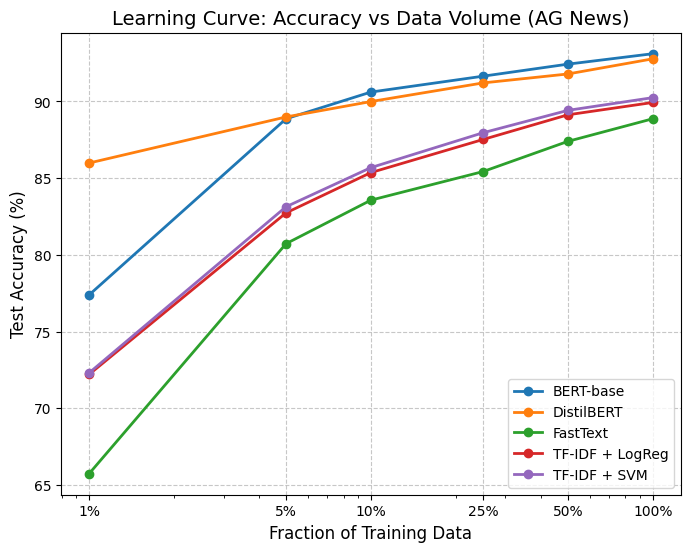

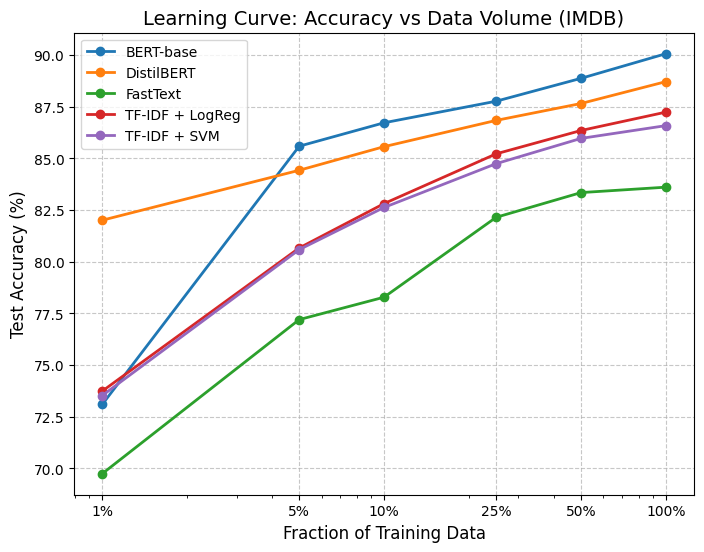

In [43]:
try:
    df_eff = pd.read_excel(FILE_NAME, sheet_name=1, header=2)
    df_eff = clean_cols(df_eff)
    
    eff_summary = df_eff.groupby(['dataset', 'model', 'fraction'])['Accuracy'].mean().reset_index()
    
    datasets = eff_summary['dataset'].unique()
    for ds in datasets:
        plt.figure(figsize=(8, 6))
        ds_data = eff_summary[eff_summary['dataset'] == ds]
        
        models = ds_data['model'].unique()
        for m in models:
            m_data = ds_data[ds_data['model'] == m].sort_values(by='fraction')
            plt.plot(m_data['fraction'], m_data['Accuracy'] * 100, marker='o', label=m, linewidth=2)
        
        plt.title(f'Learning Curve: Accuracy vs Data Volume ({ds})', fontsize=14)
        plt.xlabel('Fraction of Training Data', fontsize=12)
        plt.ylabel('Test Accuracy (%)', fontsize=12)
        plt.xscale('log') 
        plt.xticks([0.01, 0.05, 0.1, 0.25, 0.5, 1.0], ['1%', '5%', '10%', '25%', '50%', '100%'])
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        fig_name = f'Learning_Curve_{ds}.png'
        plt.savefig(fig_name, dpi=300, bbox_inches='tight')
        
except Exception as e:
    print(f"Failed to generate learning curves: {e}")

In [47]:

try:
    df_err = pd.read_excel(FILE_NAME, sheet_name=2, header=2)
    df_err = clean_cols(df_err)
    
    err_counts = df_err.groupby(['dataset', 'model', 'Failure_Type']).size().reset_index(name='error_count')
    
    datasets = err_counts['dataset'].unique()
    for ds in datasets:
        print(f"\n--- {ds} failures classified ---")
        ds_err = err_counts[err_counts['dataset'] == ds]
        models = ds_err['model'].unique()
        for m in models:
            m_err = ds_err[ds_err['model'] == m]
            print(f"model [{m}]:")
            for index, row in m_err.iterrows():
                print(f"    - {row['Failure_Type']}: {row['error_count']} cases")
                
except Exception as e:
    print(f"Failed to generate error analysis: {e}")



--- AG News failures classified ---
model [BERT-base]:
    - ambiguity: 8 cases
    - rare_vocabulary: 1 cases
    - too_short: 1 cases
model [DistilBERT]:
    - ambiguity: 6 cases
    - rare_vocabulary: 4 cases
model [Fasttext]:
    - Ambiguity: 1 cases

--- AG News  failures classified ---
model [TF-IDF+LR ]:
    - Annotation noise: 6 cases
    - other: 3 cases
    - rare_vocabulary: 1 cases
model [TF-IDF+SVM]:
    - Annotation noise: 8 cases
    - other: 2 cases

--- AG News  failures classified ---
model [Fasttext]:
    - Ambiguity: 22 cases
    - too_short: 2 cases

--- IMDB failures classified ---
model [BERT-base]:
    - ambiguity: 1 cases
    - long_text_truncation: 2 cases
    - rare_vocabulary: 4 cases
    - sarcasm_or_irony: 3 cases
model [DistilBERT]:
    - long_text_truncation: 4 cases
    - rare_vocabulary: 1 cases
    - sarcasm_or_irony: 5 cases
model [Fasttext]:
    - Ambiguity: 4 cases
    - long_text_trucation: 5 cases
    - other: 5 cases
    - rare_vocabulary: 4 ca

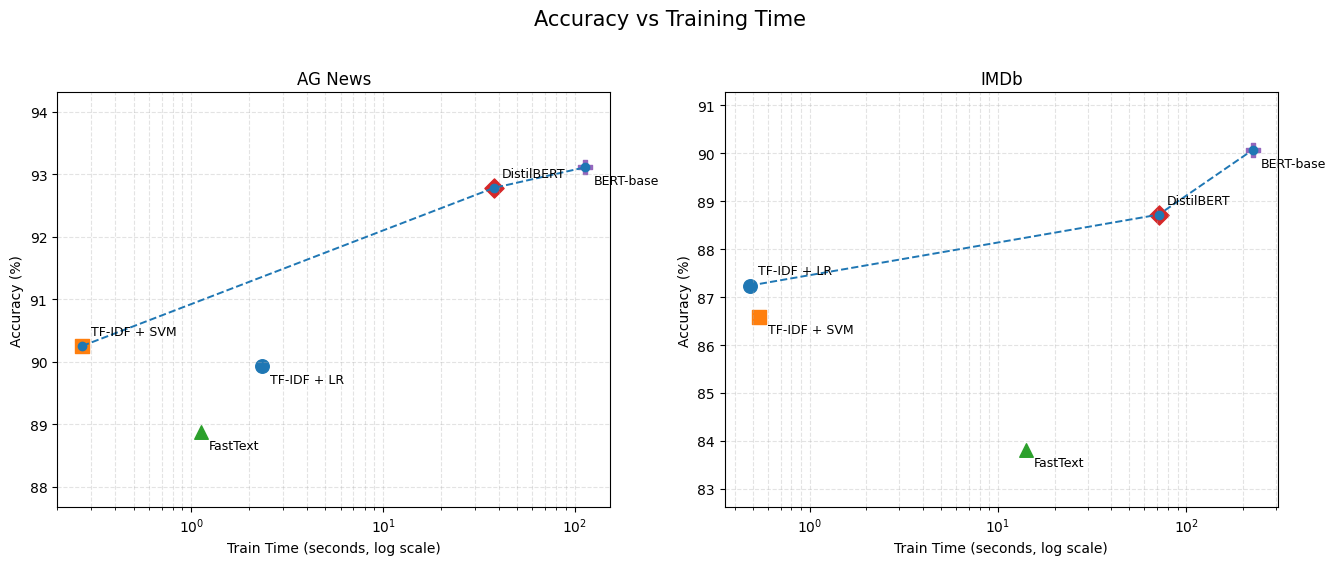

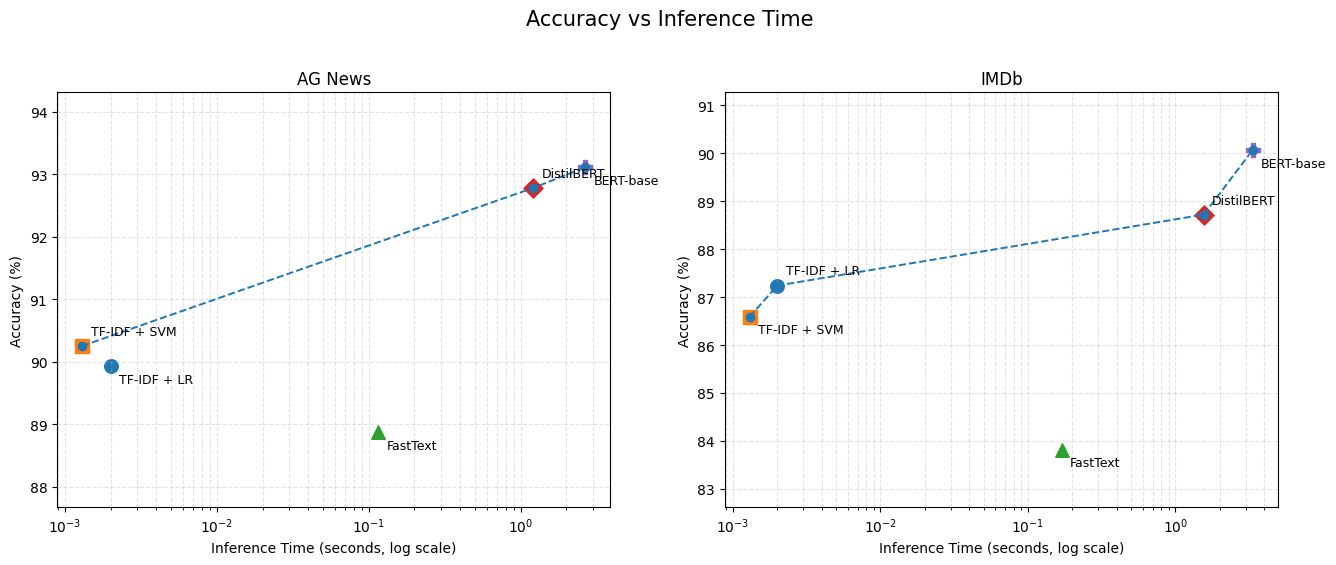


AG News | Train Time Pareto frontier
       Model  Accuracy  Train Time
TF-IDF + SVM     90.25        0.27
  DistilBERT     92.78       37.79
   BERT-base     93.11      113.15

AG News | Inference Time Pareto frontier
       Model  Accuracy  Inference Time
TF-IDF + SVM     90.25          0.0013
  DistilBERT     92.78          1.2122
   BERT-base     93.11          2.6643

IMDb | Train Time Pareto frontier
      Model  Accuracy  Train Time
TF-IDF + LR     87.24        0.48
 DistilBERT     88.72       71.47
  BERT-base     90.07      225.86

IMDb | Inference Time Pareto frontier
       Model  Accuracy  Inference Time
TF-IDF + SVM     86.59          0.0013
 TF-IDF + LR     87.24          0.0020
  DistilBERT     88.72          1.5558
   BERT-base     90.07          3.3407


In [48]:

data = [
    # AG News
    {"Dataset": "AG News", "Model": "TF-IDF + LR",  "Accuracy": 89.93, "Train Time": 2.33,   "Inference Time": 0.0020},
    {"Dataset": "AG News", "Model": "TF-IDF + SVM", "Accuracy": 90.25, "Train Time": 0.27,   "Inference Time": 0.0013},
    {"Dataset": "AG News", "Model": "FastText",     "Accuracy": 88.87, "Train Time": 1.12,   "Inference Time": 0.1159},
    {"Dataset": "AG News", "Model": "DistilBERT",   "Accuracy": 92.78, "Train Time": 37.79,  "Inference Time": 1.2122},
    {"Dataset": "AG News", "Model": "BERT-base",    "Accuracy": 93.11, "Train Time": 113.15, "Inference Time": 2.6643},

    # IMDb
    {"Dataset": "IMDb",    "Model": "TF-IDF + LR",  "Accuracy": 87.24, "Train Time": 0.48,   "Inference Time": 0.0020},
    {"Dataset": "IMDb",    "Model": "TF-IDF + SVM", "Accuracy": 86.59, "Train Time": 0.54,   "Inference Time": 0.0013},
    {"Dataset": "IMDb",    "Model": "FastText",     "Accuracy": 83.82, "Train Time": 14.06,  "Inference Time": 0.1691},
    {"Dataset": "IMDb",    "Model": "DistilBERT",   "Accuracy": 88.72, "Train Time": 71.47,  "Inference Time": 1.5558},
    {"Dataset": "IMDb",    "Model": "BERT-base",    "Accuracy": 90.07, "Train Time": 225.86, "Inference Time": 3.3407},
]
df = pd.DataFrame(data)

# =========================================================
# 2. Pareto frontier
#    Higher accuracy + lower time = better
# =========================================================
def get_pareto_frontier(df_sub, time_col, acc_col="Accuracy"):
    frontier_idx = []
    for i, row in df_sub.iterrows():
        dominated = (
            ((df_sub[acc_col] >= row[acc_col]) & (df_sub[time_col] <= row[time_col])) &
            ((df_sub[acc_col] > row[acc_col]) | (df_sub[time_col] < row[time_col]))
        ).any()
        if not dominated:
            frontier_idx.append(i)
    return df_sub.loc[frontier_idx].sort_values(by=time_col)

# =========================================================
# 3. Marker mapping
# =========================================================
marker_map = {
    "TF-IDF + LR": "o",
    "TF-IDF + SVM": "s",
    "FastText": "^",
    "DistilBERT": "D",
    "BERT-base": "P",
}

# =========================================================
# 4. Label offsets
# =========================================================
label_offsets = {
    ("AG News", "Train Time"): {
        "TF-IDF + LR":  (6, -12),
        "TF-IDF + SVM": (6, 8),
        "FastText":     (6, -12),
        "DistilBERT":   (6, 8),
        "BERT-base":    (6, -12),
    },
    ("IMDb", "Train Time"): {
        "TF-IDF + LR":  (6, 8),
        "TF-IDF + SVM": (6, -12),
        "FastText":     (6, -12),
        "DistilBERT":   (6, 8),
        "BERT-base":    (6, -12),
    },
    ("AG News", "Inference Time"): {
        "TF-IDF + LR":  (6, -12),
        "TF-IDF + SVM": (6, 8),
        "FastText":     (6, -12),
        "DistilBERT":   (6, 8),
        "BERT-base":    (6, -12),
    },
    ("IMDb", "Inference Time"): {
        "TF-IDF + LR":  (6, 8),
        "TF-IDF + SVM": (6, -12),
        "FastText":     (6, -12),
        "DistilBERT":   (6, 8),
        "BERT-base":    (6, -12),
    }
}

# =========================================================
# 5. Single subplot function
# =========================================================
def plot_panel(ax, df_sub, dataset_name, time_col):
    frontier = get_pareto_frontier(df_sub, time_col)

    # plot each model with distinct marker
    for _, row in df_sub.iterrows():
        ax.scatter(
            row[time_col],
            row["Accuracy"],
            s=95,
            marker=marker_map[row["Model"]]
        )

        dx, dy = label_offsets.get((dataset_name, time_col), {}).get(row["Model"], (6, 6))
        ax.annotate(
            row["Model"],
            (row[time_col], row["Accuracy"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9
        )

    # pareto frontier
    ax.plot(
        frontier[time_col],
        frontier["Accuracy"],
        linestyle="--",
        marker="o",
        linewidth=1.4
    )

    # formatting
    ax.set_xscale("log")
    ax.set_xlabel(f"{time_col} (seconds, log scale)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(dataset_name, fontsize=12)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

    y_min = df_sub["Accuracy"].min()
    y_max = df_sub["Accuracy"].max()
    ax.set_ylim(y_min - 1.2, y_max + 1.2)

# =========================================================
# 6. Figure 1: Accuracy vs Training Time
# =========================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(13.5, 5.5))

for ax, dataset in zip(axes1, ["AG News", "IMDb"]):
    plot_panel(
        ax=ax,
        df_sub=df[df["Dataset"] == dataset].copy(),
        dataset_name=dataset,
        time_col="Train Time"
    )

fig1.suptitle("Accuracy vs Training Time", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("figure_train_time_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 7. Figure 2: Accuracy vs Inference Time
# =========================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(13.5, 5.5))

for ax, dataset in zip(axes2, ["AG News", "IMDb"]):
    plot_panel(
        ax=ax,
        df_sub=df[df["Dataset"] == dataset].copy(),
        dataset_name=dataset,
        time_col="Inference Time"
    )

fig2.suptitle("Accuracy vs Inference Time", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("figure_inference_time_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 8. Print Pareto frontier tables
# =========================================================
for dataset in ["AG News", "IMDb"]:
    for time_col in ["Train Time", "Inference Time"]:
        frontier = get_pareto_frontier(df[df["Dataset"] == dataset].copy(), time_col)
        print(f"\n{dataset} | {time_col} Pareto frontier")
        print(frontier[["Model", "Accuracy", time_col]].to_string(index=False))